<a href="https://colab.research.google.com/github/oseiagyepom-oss/INFO648/blob/main/Lesson_12/MarketBasket_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Market Basket Analysis

Market basket analysis is an unsupervised learning technique used to uncover associations between items in transactional data — for example, identifying that customers who buy tortilla chips are also likely to buy salsa. It works by applying the **Apriori algorithm** to find frequent itemsets, then generating association rules evaluated by metrics like **support** (how often items appear together), **confidence** (how reliably one item predicts another), and **lift** (how much more likely the association is vs. random chance). In Python, the mlxtend library provides TransactionEncoder, apriori, and association_rules to streamline the full pipeline from raw transaction data to ranked rules. The results can be visualized as a network graph using `networkx`, where nodes represent products and edge weights reflect the strength of association.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

In [2]:
import pandas as pd

In [3]:
orders=pd.read_csv('/content/order_products__prior.csv')
products=pd.read_csv('/content/products.csv')
departments=pd.read_csv('/content/departments.csv')

In [6]:
from numpy._core.fromnumeric import prod
#orders.head()
#products.head()
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [7]:
temp=orders.merge(products,on='product_id',how='inner')

In [8]:
temp.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2,33120,1,1,Organic Egg Whites,86,16
1,2,28985,2,1,Michigan Organic Kale,83,4
2,2,9327,3,0,Garlic Powder,104,13
3,2,45918,4,1,Coconut Butter,19,13
4,2,30035,5,0,Natural Sweetener,17,13


In [9]:
df=temp.merge(departments,on='department_id',how='inner')

In [ ]:
df.head()

In [10]:
df['department'].unique()

array(['dairy eggs', 'produce', 'pantry', 'meat seafood', 'bakery',
       'personal care', 'snacks', 'breakfast', 'beverages', 'deli',
       'household', 'international', 'dry goods pasta', 'frozen',
       'canned goods', 'babies', 'pets', 'alcohol', 'bulk', 'missing',
       'other'], dtype=object)

In [11]:
df2 = df[df['department'].isin(['international'])]

In [12]:
df2.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,department
37,5,9633,8,1,"Matzos, Thin, Tea",33,6,international
133,14,23032,9,0,Sriracha Chili Sauce,66,6,international
156,18,4802,13,0,"Sesame Oil, Pure",66,6,international
542,65,25170,3,0,Soy Sauce,66,6,international
742,87,38770,5,0,Chopped Green Chiles,30,6,international


In [14]:
df2=df2[['order_id','product_name']]

In [15]:
df2[df2['order_id']==398853]

,order_id,product_name
3776246,398853,Korean Kimchi
3776248,398853,Soy Ginger Sauce
3776249,398853,Less Salt Soy Sauce
3776254,398853,Ponzu Sauce
3776255,398853,Stir-fry Rice Noodles
3776256,398853,Teriyaki Sauce
3776257,398853,Asian BBQ Sauce
3776258,398853,Sweet Red Chili Dipping & All-Purpose Sauce
3776259,398853,Spicy Ginger Teriyaki Yummy Marinade & Simmer ...
3776260,398853,Organic Rice Vinegar


In [16]:
sample_orders=df2['order_id'].unique()[:30000]

In [17]:
df2=df2[df2['order_id'].isin(sample_orders)]

In [18]:
df2.shape

(36385, 2)

In [19]:
df2.head()

,order_id,product_name
37,5,"Matzos, Thin, Tea"
133,14,Sriracha Chili Sauce
156,18,"Sesame Oil, Pure"
542,65,Soy Sauce
742,87,Chopped Green Chiles


In [20]:
#unstack() takes values that are stacked vertically under an index level and spreads them out sideways into separate columns.
basket = (
    df2.groupby(['order_id', 'product_name'])['product_name']
    .count().unstack().fillna(0)
)

In [21]:
basket.head()

product_name,1 Step Kashmir Spinach Indian Cuisine,1 Step-1 Minute Noodles Toasted Sesame,1-Step 1-Minute Paneer Makhani,100% Juice Sparkling Kosher Grape,100% Pure Premium Canola Oil,100% Pure Sesame Seed Oil,100% Whole Soy Organic Gluten Free Tamari Soy Sauce,100% Whole Wheat No Salt Added Matzos,100% Whole Wheat Panko,37% Less Sodium Soy Sauce,...,Yaki Nori Roasted Seaweed Sheets,Yamaimo Soba Buckwheat Noodles,Yasai Fumi Furikake Rice Seasoning,Yellow Corn Taco Dinner Kit,Yellow Corn Taco Shells,Yellow Corn Taco Shells - 12 CT,Yellow Curry Paste,Yolk Free Medium Noodles,Yuzu Ponzu Dressing,Zucchini Pancakes
order_id,,,,,,,,,,,,,,,,,,,,,
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
basket.loc[398853].sort_values(ascending=False)

,398853
product_name,
Thin Rice Noodles,1
"Rick Sticks, Vermicelli",1
Spicy Ginger Teriyaki Yummy Marinade & Simmer Sauce,1
Organic Rice Vinegar,1
Teriyaki Sauce,1
...,...
Kelp Atlantic Kombu,0
Kelp Noodles,0
Kelp Noodles with Green Tea,0


In [23]:
basket.shape

(30000, 1016)

In [24]:
basket=basket.map(lambda x: 1 if x>0 else 0)

In [28]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
#mlxend is built on top of sklearn and is the goto for market basket
#fpgrowth lets us put a threshold on support so rare items are ignored
#association rules like support, confidence, lift
from mlxtend.frequent_patterns import fpgrowth, association_rules
frequent = fpgrowth(basket, min_support=0.0002, use_colnames=True,max_len=2)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [29]:
frequent.shape

(746, 2)

In [30]:
frequent.head()

,support,itemsets
0,0.019600,(Sriracha Chili Sauce)
1,0.000933,"(Sesame Oil, Pure)"
2,0.010067,(Soy Sauce)
3,0.002900,(Chopped Green Chiles)
4,0.006433,(Lightly Breaded Fish Sticks)


In [31]:
#feed the frequent dataframe into association_rules to determine the confidence and lift
rules = association_rules(frequent, metric="lift", min_threshold=0)

In [32]:
rules.shape

(258, 14)

**Antecedent = the items you start with (the condition / IF part of the rule).**

# {flashlight} → {batteries}

# Antecedent = {flashlight} → what comes first (“IF”)

# Consequent = {batteries} → what comes after (“THEN”)

In [33]:
#Then just sort or filter as desired - all in pandas dataframes so easy
rules = rules.sort_values(by='lift', ascending=False)
#rules[['antecedents','consequents','support','confidence','lift']].tail(100)


In [34]:
rules=rules[(rules['lift']>1.5) & (rules['lift']<5)]

In [35]:
rules[['antecedents','consequents','support','confidence','lift']].tail(100)

,antecedents,consequents,support,confidence,lift
17,(Organic Soba),(Organic Udon Japanese Wheat Noodles),0.000333,0.027855,4.802613
16,(Organic Udon Japanese Wheat Noodles),(Organic Soba),0.000333,0.057471,4.802613
131,(Taco Seasoning),(Organic Yellow Corn Taco Shells 12 Count),0.000533,0.013445,4.583652
130,(Organic Yellow Corn Taco Shells 12 Count),(Taco Seasoning),0.000533,0.181818,4.583652
37,(Organic Sea Salt Roasted Seaweed Snacks),(Organic Roasted Seaweed Snacks Teriyaki),0.001267,0.027556,3.625816
36,(Organic Roasted Seaweed Snacks Teriyaki),(Organic Sea Salt Roasted Seaweed Snacks),0.001267,0.166667,3.625816
48,(Unsweetened Coconut Milk),(Green Curry Paste),0.000200,0.035294,3.506038
49,(Green Curry Paste),(Unsweetened Coconut Milk),0.000200,0.019868,3.506038
40,(Roasted Sesame Seaweed Snacks),(Organic Roasted Seaweed Snacks Teriyaki),0.000400,0.025641,3.373819
41,(Organic Roasted Seaweed Snacks Teriyaki),(Roasted Sesame Seaweed Snacks),0.000400,0.052632,3.373819


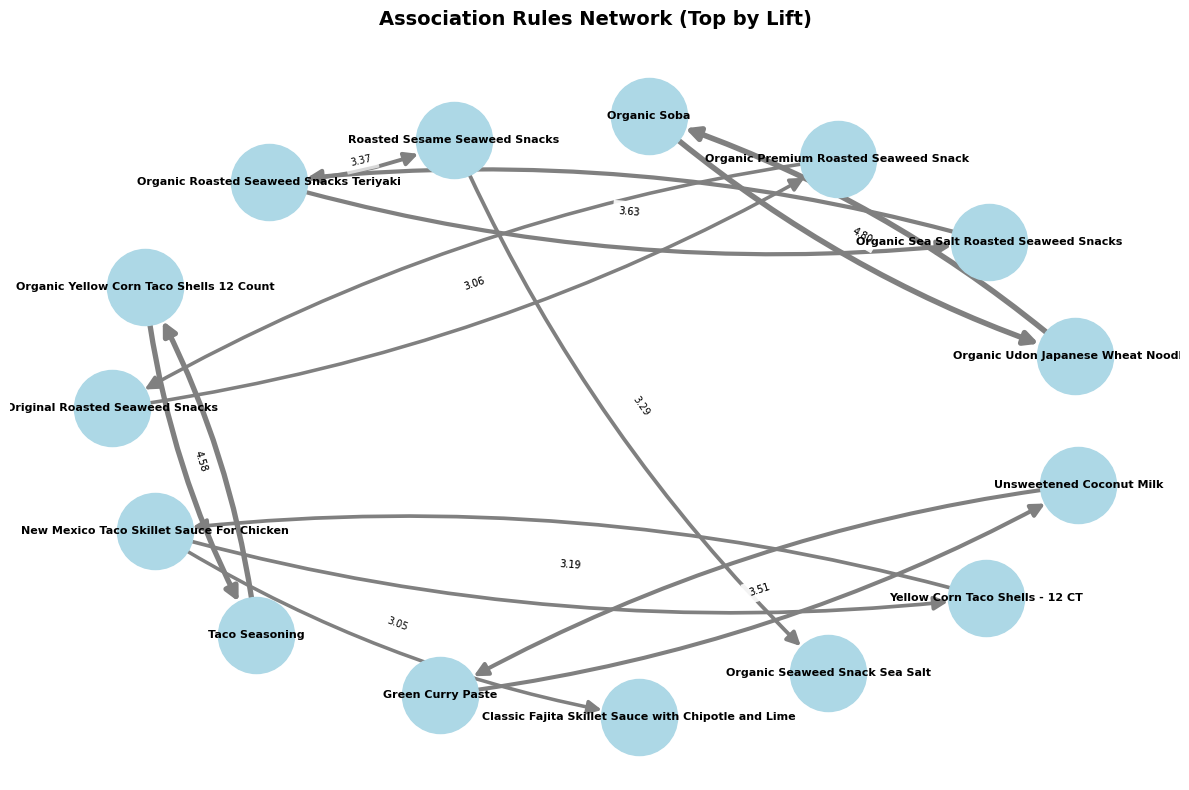

In [36]:
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use('default')

G = nx.DiGraph()

top_rules = rules.sort_values(by='lift', ascending=False)
top_rules = top_rules.drop_duplicates(subset='consequents').head(15)

for _, row in top_rules.iterrows():
    a = list(row['antecedents'])[0]
    b = list(row['consequents'])[0]
    G.add_edge(a, b, weight=row['lift'])

fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
ax.set_facecolor('white')

pos = nx.spring_layout(G, k=30, iterations=200, seed=42)

raw_weights = [G[u][v]['weight'] for u, v in G.edges()]
norm_weights = [w / max(raw_weights) * 4 for w in raw_weights]

nx.draw(
    G, pos,
    ax=ax,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    edge_color="gray",
    font_color="black",
    font_size=8,
    font_weight='bold',
    width=norm_weights,
    arrows=True,
    arrowsize=20,
    connectionstyle='arc3,rad=0.1'
)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    ax=ax,
    font_size=7,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

plt.title("Association Rules Network (Top by Lift)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [37]:
# How often does it actually appear?
rules[rules['antecedents'].astype(str).str.contains('New Mexico')]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
100,(New Mexico Taco Skillet Sauce For Chicken),(Yellow Corn Taco Shells - 12 CT),0.019133,0.005467,0.000333,0.017422,3.186879,1.0,0.000229,1.012167,0.699599,0.013736,0.012021,0.039199
73,(New Mexico Taco Skillet Sauce For Chicken),(Classic Fajita Skillet Sauce with Chipotle an...,0.019133,0.004567,0.000267,0.013937,3.051960,1.0,0.000179,1.009503,0.685457,0.011380,0.009414,0.036166
60,(New Mexico Taco Skillet Sauce For Chicken),(Yellow Corn Taco Shells),0.019133,0.006767,0.000233,0.012195,1.802235,1.0,0.000104,1.005495,0.453816,0.009091,0.005465,0.023339
82,(New Mexico Taco Skillet Sauce For Chicken),(Green Chile Enchilada Sauce),0.019133,0.008433,0.000267,0.013937,1.652642,1.0,0.000105,1.005582,0.402612,0.009768,0.005551,0.022779


In [38]:
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
# Convert frozensets to strings (important!)
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

fig = px.scatter(
    rules,
    x="confidence",
    y="lift",
    size="support",
    hover_data={
        "antecedents_str": True,
        "consequents_str": True,
        "support": True,
        "confidence": True,
        "lift": True
    },
    title="Association Rules: Confidence vs Lift"
)

fig.show()